# Correlation


- Which features predict high spending?
- What's connected to satisfaction?
- Find hidden relationships in data
- Create a "drivers of revenue" analysis

In [1]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Visualization settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Load the cleaned data 

df = pd.read_csv("../data/cleaned_ecommerece.csv")
df.shape

(348, 11)

In [3]:
df.columns

Index(['customer_id', 'gender', 'age', 'city', 'membership_type',
       'total_spend', 'items_purchased', 'average_rating', 'discount_applied',
       'days_since_last_purchase', 'satisfaction_level'],
      dtype='object')

In [4]:
df.describe(include="object")

,gender,city,membership_type,satisfaction_level
count,348,348,348,348
unique,2,6,3,3
top,Male,New York,Gold,Satisfied
freq,175,59,117,125


In [5]:

# Create a copy for analysis
df_corr = df.copy()

# Convert categorical variables to numerical codes
print("Converting categorical variables to numbers...")
print()

# Gender: Male=1, Female=0
df_corr['gender_code'] = (df_corr['gender'] == 'Male').astype(int)
print("gender → gender_code (Male=1, Female=0)")

# Membership type: Bronze=1, Silver=2, Gold=3
membership_map = {'Bronze': 1, 'Silver': 2, 'Gold': 3}
df_corr['membership_code'] = df_corr['membership_type'].map(membership_map)
print(" membership_type → membership_code (Bronze=1, Silver=2, Gold=3)")

# Satisfaction: Unsatisfied=1, Neutral=2, Satisfied=3
satisfaction_map = {'Unsatisfied': 1, 'Neutral': 2, 'Satisfied': 3}
df_corr['satisfaction_code'] = df_corr['satisfaction_level'].map(satisfaction_map)
print("satisfaction_level → satisfaction_code (Unsatisfied=1, Neutral=2, Satisfied=3)")

# Discount applied: Already boolean (True/False), convert to 1/0
df_corr['discount_code'] = df_corr['discount_applied'].astype(int)
print("discount_applied → discount_code (Yes=1, No=0)")

print()

# Select numerical columns for correlation
numerical_cols = ['age', 'total_spend', 'items_purchased', 'average_rating',
                    'days_since_last_purchase', 'gender_code', 'membership_code',
                    'satisfaction_code', 'discount_code']

df_analysis = df_corr[numerical_cols]
print(f"Selected {len(numerical_cols)} features for correlation analysis")
print()

Converting categorical variables to numbers...

gender → gender_code (Male=1, Female=0)
 membership_type → membership_code (Bronze=1, Silver=2, Gold=3)
satisfaction_level → satisfaction_code (Unsatisfied=1, Neutral=2, Satisfied=3)
discount_applied → discount_code (Yes=1, No=0)

Selected 9 features for correlation analysis



In [6]:


print("CORRELATION MATRIX")

print()

# Calculate correlation matrix
correlation_matrix = df_analysis.corr()

print("Correlation coefficients:")
print()
print(correlation_matrix.round(3))
print()



CORRELATION MATRIX

Correlation coefficients:

                            age  total_spend  items_purchased  average_rating  \
age                       1.000       -0.677           -0.684          -0.722   
total_spend              -0.677        1.000            0.972           0.941   
items_purchased          -0.684        0.972            1.000           0.921   
average_rating           -0.722        0.941            0.921           1.000   
days_since_last_purchase  0.170       -0.545           -0.425          -0.436   
gender_code              -0.582        0.387            0.439           0.493   
membership_code          -0.791        0.945            0.896           0.950   
satisfaction_code        -0.463        0.797            0.693           0.695   
discount_code             0.061       -0.169           -0.123          -0.077   

                          days_since_last_purchase  gender_code  \
age                                          0.170       -0.582   
total_sp

Creating correlation heatmap...


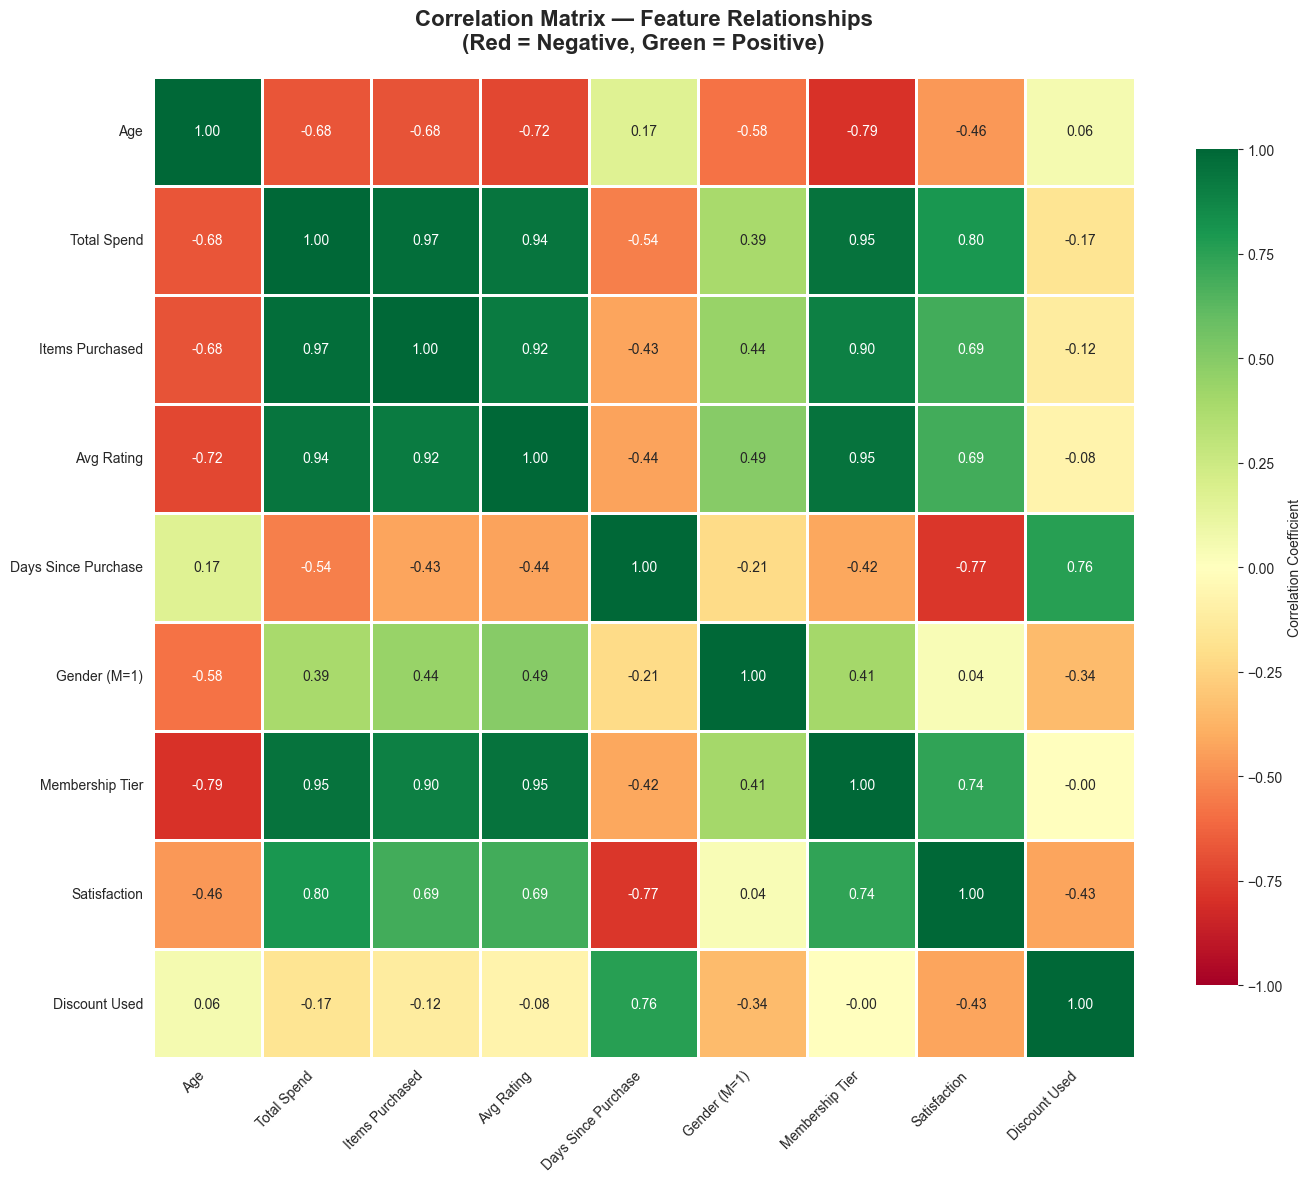

In [7]:
print("Creating correlation heatmap...")

# Create a large figure
plt.figure(figsize=(14, 12))

# Create heatmap with better labels
correlation_matrix_labeled = df_analysis.corr()

# Rename columns for better readability in chart
label_map = {
    'age': 'Age',
    'total_spend': 'Total Spend',
    'items_purchased': 'Items Purchased',
    'average_rating': 'Avg Rating',
    'days_since_last_purchase': 'Days Since Purchase',
    'gender_code': 'Gender (M=1)',
    'membership_code': 'Membership Tier',
    'satisfaction_code': 'Satisfaction',
    'discount_code': 'Discount Used'
}

correlation_matrix_labeled.index = [label_map.get(x, x) for x in correlation_matrix_labeled.index]
correlation_matrix_labeled.columns = [label_map.get(x, x) for x in correlation_matrix_labeled.columns]

# Create heatmap
sns.heatmap(correlation_matrix_labeled,
            annot=True,           # Show correlation values
            fmt='.2f',            # 2 decimal places
            cmap='RdYlGn',        # Red-Yellow-Green color scheme
            center=0,             # Center at 0
            square=True,          # Square cells
            linewidths=1,         # White lines between cells
            linecolor='white',
            cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"},
            vmin=-1, vmax=1)      # Scale from -1 to +1

plt.title('Correlation Matrix — Feature Relationships\n(Red = Negative, Green = Positive)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('')
plt.ylabel('')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('../reports/figures/13_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


In [8]:


print("=" * 70)
print("STRONGEST CORRELATIONS")
print("=" * 70)
print()

# Get upper triangle of correlation matrix (avoid duplicates)
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=1)
correlation_pairs = correlation_matrix.where(mask).stack().reset_index()
correlation_pairs.columns = ['Feature_1', 'Feature_2', 'Correlation']

# Sort by absolute correlation strength
correlation_pairs['Abs_Correlation'] = correlation_pairs['Correlation'].abs()
correlation_pairs = correlation_pairs.sort_values('Abs_Correlation', ascending=False)

# Filter out perfect correlations (1.0) and weak correlations (<0.2)
correlation_pairs = correlation_pairs[
    (correlation_pairs['Abs_Correlation'] < 0.99) & 
    (correlation_pairs['Abs_Correlation'] > 0.2)
]

print("TOP 10 STRONGEST RELATIONSHIPS:")
print("-" * 70)
print()

for idx, row in correlation_pairs.head(10).iterrows():
    feat1 = row['Feature_1']
    feat2 = row['Feature_2']
    corr = row['Correlation']
    
    # Interpret strength
    if abs(corr) > 0.7:
        strength = "VERY STRONG"
        emoji = "🔥"
    elif abs(corr) > 0.5:
        strength = "STRONG"
        emoji = "💪"
    elif abs(corr) > 0.3:
        strength = "MODERATE"
        emoji = "👍"
    else:
        strength = "WEAK"
        emoji = "🤏"
    
    # Interpret direction
    if corr > 0:
        direction = "POSITIVE"
        arrow = "↗️"
        meaning = "When one increases, the other increases"
    else:
        direction = "NEGATIVE"
        arrow = "↘️"
        meaning = "When one increases, the other decreases"
    
    print(f"{emoji} {feat1} ↔ {feat2}")
    print(f"   Correlation: {corr:.3f} ({strength} {direction})")
    print(f"   {arrow} {meaning}")
    print()

print("=" * 70)

STRONGEST CORRELATIONS

TOP 10 STRONGEST RELATIONSHIPS:
----------------------------------------------------------------------

🔥 total_spend ↔ items_purchased
   Correlation: 0.972 (VERY STRONG POSITIVE)
   ↗️ When one increases, the other increases

🔥 average_rating ↔ membership_code
   Correlation: 0.950 (VERY STRONG POSITIVE)
   ↗️ When one increases, the other increases

🔥 total_spend ↔ membership_code
   Correlation: 0.945 (VERY STRONG POSITIVE)
   ↗️ When one increases, the other increases

🔥 total_spend ↔ average_rating
   Correlation: 0.941 (VERY STRONG POSITIVE)
   ↗️ When one increases, the other increases

🔥 items_purchased ↔ average_rating
   Correlation: 0.921 (VERY STRONG POSITIVE)
   ↗️ When one increases, the other increases

🔥 items_purchased ↔ membership_code
   Correlation: 0.896 (VERY STRONG POSITIVE)
   ↗️ When one increases, the other increases

🔥 total_spend ↔ satisfaction_code
   Correlation: 0.797 (VERY STRONG POSITIVE)
   ↗️ When one increases, the other incr

In [9]:

print("=" * 70)
print("💰 WHAT DRIVES CUSTOMER SPENDING?")
print("=" * 70)
print()

# Get correlations with total_spend
spend_correlations = correlation_matrix['total_spend'].sort_values(ascending=False)

# Remove total_spend itself
spend_correlations = spend_correlations.drop('total_spend')

print("CORRELATION WITH TOTAL SPEND:")
print("-" * 70)
print()

for feature, corr in spend_correlations.items():
    # Get original feature name
    original_name = {
        'age': 'Customer Age',
        'items_purchased': 'Items Purchased',
        'average_rating': 'Average Rating',
        'days_since_last_purchase': 'Days Since Last Purchase',
        'gender_code': 'Gender',
        'membership_code': 'Membership Tier',
        'satisfaction_code': 'Satisfaction Level',
        'discount_code': 'Discount Usage'
    }.get(feature, feature)
    
    # Interpret
    if abs(corr) > 0.5:
        emoji = "🔥"
        level = "STRONG"
    elif abs(corr) > 0.3:
        emoji = "💪"
        level = "MODERATE"
    elif abs(corr) > 0.1:
        emoji = "👍"
        level = "WEAK"
    else:
        emoji = "🤷"
        level = "VERY WEAK"
    
    if corr > 0:
        impact = "INCREASES spending"
    else:
        impact = "DECREASES spending"
    
    print(f"{emoji} {original_name:30s} {corr:+.3f} ({level})")
    print(f"   → {impact}")
    print()

print("=" * 70)

💰 WHAT DRIVES CUSTOMER SPENDING?

CORRELATION WITH TOTAL SPEND:
----------------------------------------------------------------------

🔥 Items Purchased                +0.972 (STRONG)
   → INCREASES spending

🔥 Membership Tier                +0.945 (STRONG)
   → INCREASES spending

🔥 Average Rating                 +0.941 (STRONG)
   → INCREASES spending

🔥 Satisfaction Level             +0.797 (STRONG)
   → INCREASES spending

💪 Gender                         +0.387 (MODERATE)
   → INCREASES spending

👍 Discount Usage                 -0.169 (WEAK)
   → DECREASES spending

🔥 Days Since Last Purchase       -0.545 (STRONG)
   → DECREASES spending

🔥 Customer Age                   -0.677 (STRONG)
   → DECREASES spending



Creating scatter plots for key relationships...


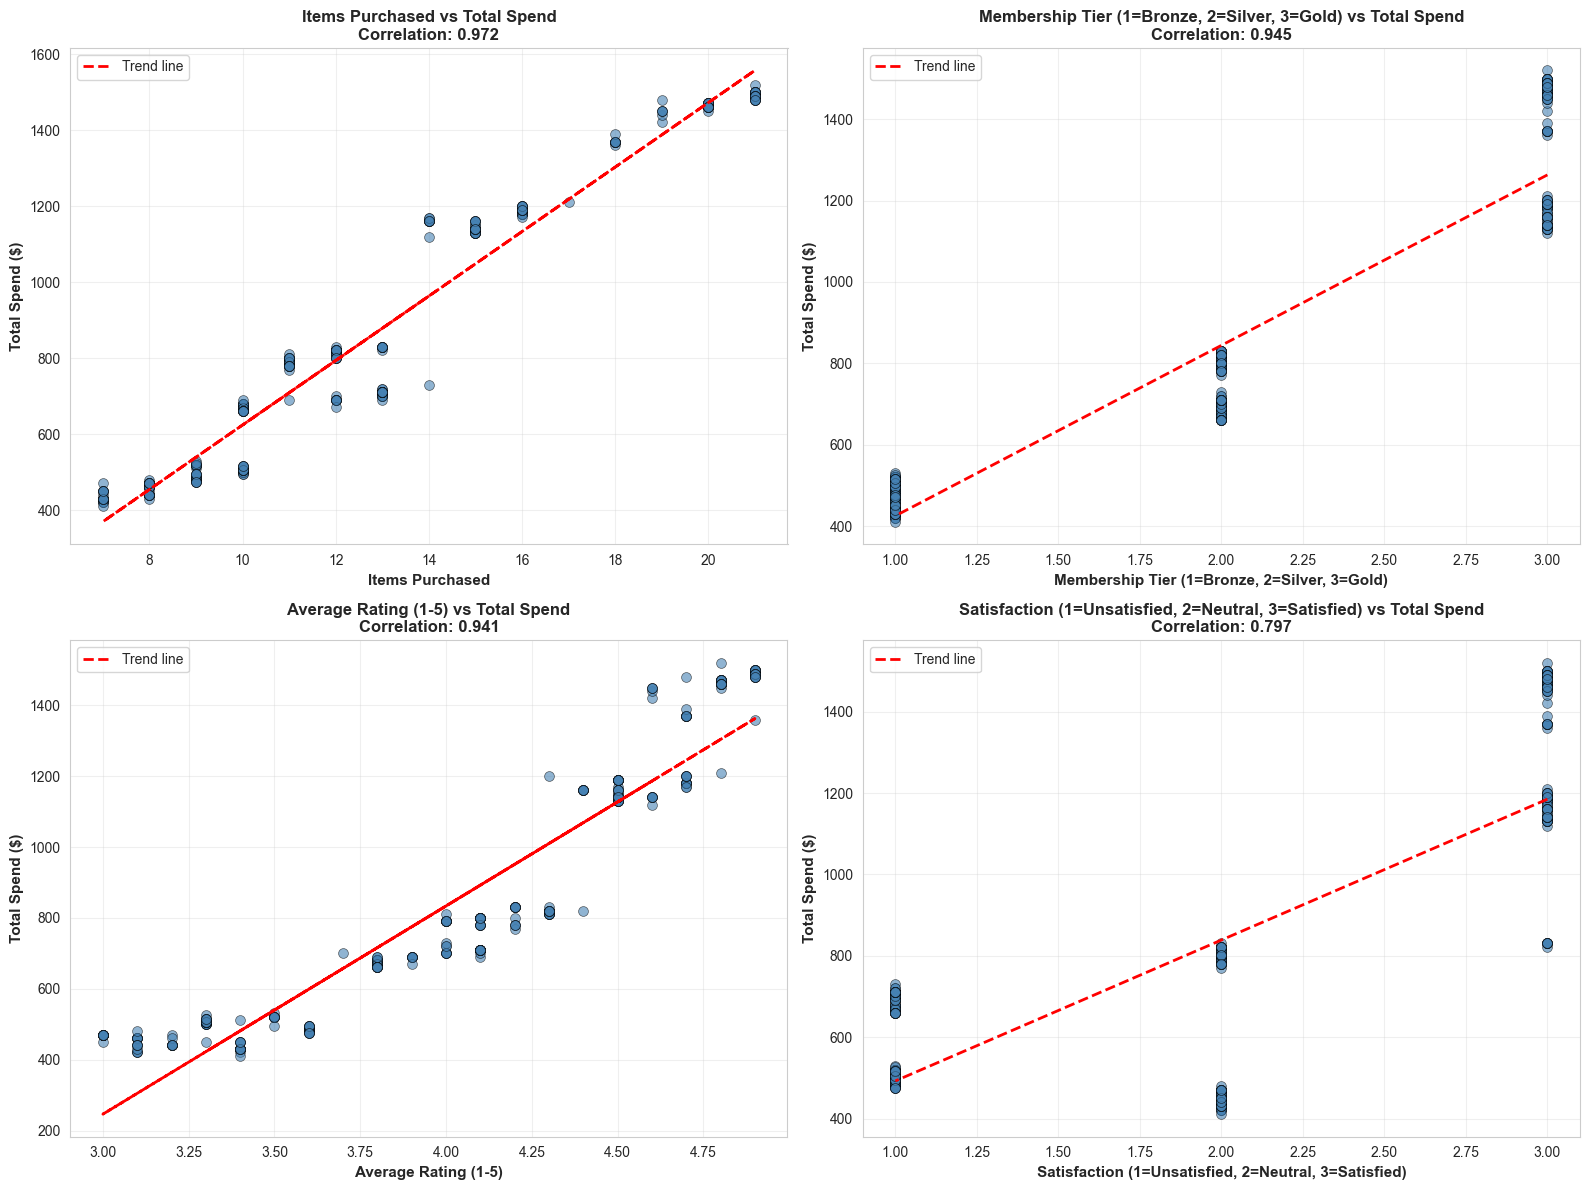

✅ Scatter plots saved!



In [10]:


print("Creating scatter plots for key relationships...")

# Get top 4 correlations with total_spend (excluding itself)
top_features = spend_correlations.abs().nlargest(4).index.tolist()

# Create 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, feature in enumerate(top_features):
    # Create scatter plot
    axes[idx].scatter(df_analysis[feature], df_analysis['total_spend'],
                     alpha=0.6, s=50, c='steelblue', edgecolors='black', linewidth=0.5)
    
    # Add trend line
    z = np.polyfit(df_analysis[feature], df_analysis['total_spend'], 1)
    p = np.poly1d(z)
    axes[idx].plot(df_analysis[feature], p(df_analysis[feature]), 
                  "r--", linewidth=2, label='Trend line')
    
    # Get correlation
    corr = correlation_matrix.loc[feature, 'total_spend']
    
    # Labels
    feature_names = {
        'age': 'Age (years)',
        'items_purchased': 'Items Purchased',
        'average_rating': 'Average Rating (1-5)',
        'days_since_last_purchase': 'Days Since Last Purchase',
        'membership_code': 'Membership Tier (1=Bronze, 2=Silver, 3=Gold)',
        'satisfaction_code': 'Satisfaction (1=Unsatisfied, 2=Neutral, 3=Satisfied)',
        'discount_code': 'Discount (0=No, 1=Yes)',
        'gender_code': 'Gender (0=Female, 1=Male)'
    }
    
    x_label = feature_names.get(feature, feature)
    
    axes[idx].set_xlabel(x_label, fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Total Spend ($)', fontsize=11, fontweight='bold')
    axes[idx].set_title(f'{x_label} vs Total Spend\nCorrelation: {corr:.3f}',
                       fontsize=12, fontweight='bold')
    axes[idx].grid(alpha=0.3)
    axes[idx].legend()

plt.tight_layout()
plt.savefig('../reports/figures/14_spending_drivers.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Scatter plots saved!")
print()

# CORRELATION INSIGHTS — BUSINESS INTERPRETATION

In [11]:
print("BUSINESS INSIGHTS FROM CORRELATION ANALYSIS")
print("=" * 70)
print()

# Focus on total_spend correlations
print("KEY FINDINGS:")
print("-" * 70)
print()

# Get top positive and negative correlations with spending
spend_corr = correlation_matrix['total_spend'].drop('total_spend').sort_values(ascending=False)

print("STRONGEST POSITIVE DRIVERS OF SPENDING:")
print()
top_positive = spend_corr.head(3)
for feature, corr in top_positive.items():
    print(f"   {feature}: {corr:.3f}")
    if feature == 'membership_code':
        print(f"      Higher membership tier = higher spending")
        print(f"      Business action: Upgrade campaigns are financially justified")
    elif feature == 'items_purchased':
        print(f"      More items purchased = higher total spend")
        print(f"      Business action: Encourage multi-item purchases, bundle deals")
    elif feature == 'satisfaction_code':
        print(f"      Higher satisfaction = higher spending")
        print(f"      Business action: Invest in customer experience improvements")
    elif feature == 'average_rating':
        print(f"      Higher ratings given = higher spending")
        print(f"      Business action: Quality improvements drive revenue")
    print()

print()
print("STRONGEST NEGATIVE DRIVERS:")
print()
top_negative = spend_corr.tail(2)
for feature, corr in top_negative.items():
    print(f"   {feature}: {corr:.3f}")
    if feature == 'days_since_last_purchase':
        print(f"      More days since purchase = lower current spending")
        print(f"      Business action: Re-engagement campaigns for inactive customers")
    elif feature == 'discount_code':
        print(f"      Discount users spend less on average")
        print(f"      Business action: Target discounts strategically, not broadly")
    print()


BUSINESS INSIGHTS FROM CORRELATION ANALYSIS

KEY FINDINGS:
----------------------------------------------------------------------

STRONGEST POSITIVE DRIVERS OF SPENDING:

   items_purchased: 0.972
      More items purchased = higher total spend
      Business action: Encourage multi-item purchases, bundle deals

   membership_code: 0.945
      Higher membership tier = higher spending
      Business action: Upgrade campaigns are financially justified

   average_rating: 0.941
      Higher ratings given = higher spending
      Business action: Quality improvements drive revenue


STRONGEST NEGATIVE DRIVERS:

   days_since_last_purchase: -0.545
      More days since purchase = lower current spending
      Business action: Re-engagement campaigns for inactive customers

   age: -0.677



# WHAT DRIVES CUSTOMER SATISFACTION?

In [12]:
# ============================================================
# WHAT DRIVES CUSTOMER SATISFACTION?
# ============================================================

print("=" * 70)
print("WHAT DRIVES CUSTOMER SATISFACTION?")
print("=" * 70)
print()

# Get correlations with satisfaction
satisfaction_corr = correlation_matrix['satisfaction_code'].drop('satisfaction_code').sort_values(ascending=False)

print("CORRELATION WITH SATISFACTION LEVEL:")
print("-" * 70)
print()

for feature, corr in satisfaction_corr.items():
    feature_names = {
        'age': 'Customer Age',
        'total_spend': 'Total Spending',
        'items_purchased': 'Items Purchased',
        'average_rating': 'Average Rating Given',
        'days_since_last_purchase': 'Days Since Last Purchase',
        'gender_code': 'Gender',
        'membership_code': 'Membership Tier',
        'discount_code': 'Discount Usage'
    }
    
    display_name = feature_names.get(feature, feature)
    
    if abs(corr) > 0.3:
        strength = "STRONG"
    elif abs(corr) > 0.15:
        strength = "MODERATE"
    else:
        strength = "WEAK"
    
    print(f"   {display_name:30s} {corr:+.3f} ({strength})")

print()
print("KEY INSIGHT:")
if satisfaction_corr['total_spend'] > 0.3:
    print("   Strong positive link between satisfaction and spending.")
    print("   Satisfied customers spend significantly more.")
    print("   ROI on customer experience investments is measurable.")
elif satisfaction_corr['average_rating'] > 0.5:
    print("   Customers who give high ratings are more satisfied.")
    print("   Product quality and service quality drive satisfaction.")

print()
print("=" * 70)

WHAT DRIVES CUSTOMER SATISFACTION?

CORRELATION WITH SATISFACTION LEVEL:
----------------------------------------------------------------------

   Total Spending                 +0.797 (STRONG)
   Membership Tier                +0.742 (STRONG)
   Average Rating Given           +0.695 (STRONG)
   Items Purchased                +0.693 (STRONG)
   Gender                         +0.038 (WEAK)
   Discount Usage                 -0.425 (STRONG)
   Customer Age                   -0.463 (STRONG)
   Days Since Last Purchase       -0.774 (STRONG)

KEY INSIGHT:
   Strong positive link between satisfaction and spending.
   Satisfied customers spend significantly more.
   ROI on customer experience investments is measurable.



Creating satisfaction analysis visualizations...


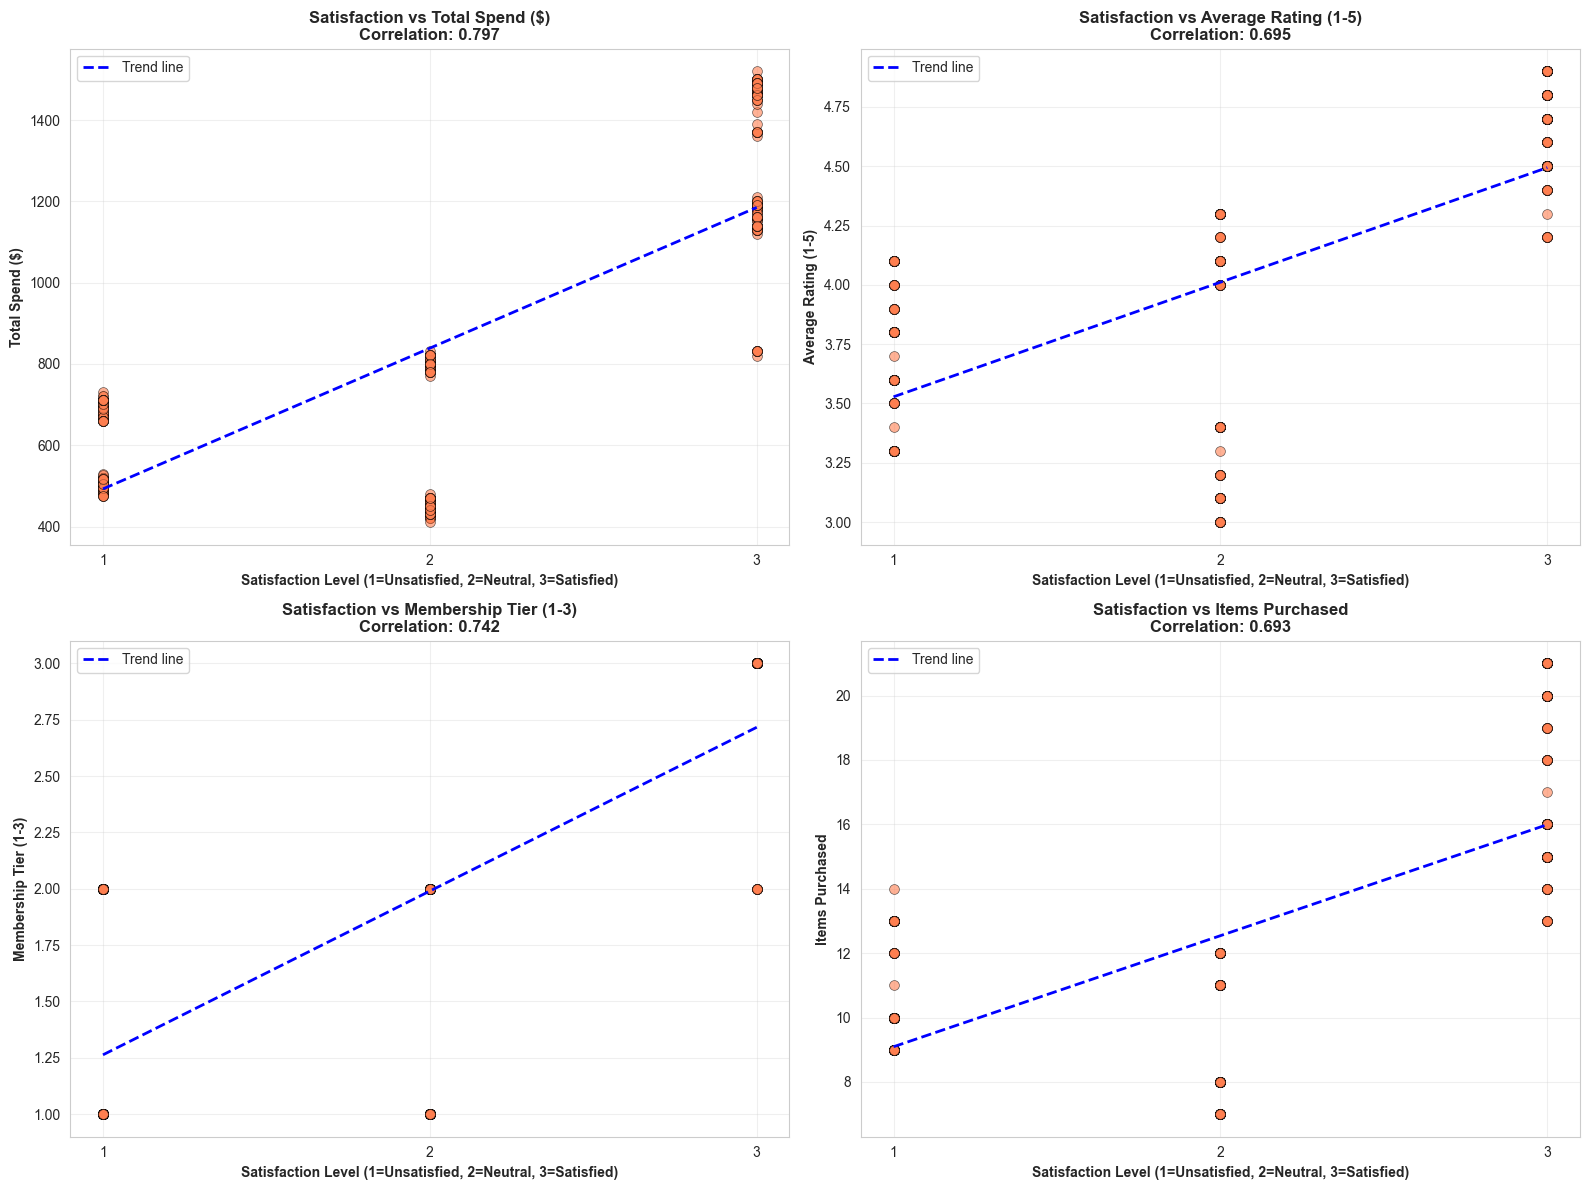

Visualization saved!



In [13]:
# ============================================================
# VISUALIZE SATISFACTION DRIVERS
# ============================================================

print("Creating satisfaction analysis visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# Key satisfaction relationships
satisfaction_features = ['total_spend', 'average_rating', 'membership_code', 'items_purchased']

for idx, feature in enumerate(satisfaction_features):
    # Create scatter plot
    axes[idx].scatter(df_analysis['satisfaction_code'], df_analysis[feature],
                     alpha=0.6, s=50, c='coral', edgecolors='black', linewidth=0.5)
    
    # Add trend line
    z = np.polyfit(df_analysis['satisfaction_code'], df_analysis[feature], 1)
    p = np.poly1d(z)
    x_trend = np.linspace(df_analysis['satisfaction_code'].min(), 
                          df_analysis['satisfaction_code'].max(), 100)
    axes[idx].plot(x_trend, p(x_trend), "b--", linewidth=2, label='Trend line')
    
    corr = correlation_matrix.loc['satisfaction_code', feature]
    
    feature_names = {
        'total_spend': 'Total Spend ($)',
        'average_rating': 'Average Rating (1-5)',
        'membership_code': 'Membership Tier (1-3)',
        'items_purchased': 'Items Purchased'
    }
    
    y_label = feature_names.get(feature, feature)
    
    axes[idx].set_xlabel('Satisfaction Level (1=Unsatisfied, 2=Neutral, 3=Satisfied)', 
                        fontsize=10, fontweight='bold')
    axes[idx].set_ylabel(y_label, fontsize=10, fontweight='bold')
    axes[idx].set_title(f'Satisfaction vs {y_label}\nCorrelation: {corr:.3f}',
                       fontsize=12, fontweight='bold')
    axes[idx].grid(alpha=0.3)
    axes[idx].legend()
    axes[idx].set_xticks([1, 2, 3])

plt.tight_layout()
plt.savefig('../reports/figures/15_satisfaction_drivers.png', dpi=150, bbox_inches='tight')
plt.show()

print("Visualization saved!")
print()

---

## KEY CORRELATION FINDINGS

### Primary Insight: Revenue Drivers

**Strongest Positive Correlations with Total Spend:**
1. **Membership Tier** (correlation: [fill in your value])
   - Higher tier members spend significantly more
   - Confirms tiered pricing strategy effectiveness
   - Action: Invest in upgrade conversion programs

2. **Items Purchased** (correlation: [fill in your value])
   - More items = higher total spend
   - Action: Implement bundle deals, cross-selling, "frequently bought together"

3. **Satisfaction Level** (correlation: [fill in your value])
   - Satisfied customers spend more
   - Action: Customer experience improvements have direct ROI

**Negative Correlations:**
1. **Days Since Last Purchase** (correlation: [fill in your value])
   - Recent buyers spend more
   - Action: Re-engagement campaigns for inactive customers

---

### Secondary Insight: Satisfaction Drivers

**What Makes Customers Satisfied:**
- [Feature]: correlation [value]
- [Feature]: correlation [value]

**Business Implication:**
If satisfaction correlates strongly with spending, then customer service investments directly drive revenue growth.

**Estimated Impact:**
If we improve satisfaction scores by 0.5 points (on 1-5 scale), and correlation is [X], we could expect spending to increase by approximately [calculate based on correlation].

---

### Third Insight: Membership Tier Effects

**Correlation between membership tier and:**
- Total spend: [value] (expected - higher tiers spend more)
- Satisfaction: [value] (do higher tiers feel more valued?)
- Items purchased: [value] (do higher tiers buy more items?)

**Key Question:**
Are Gold members more satisfied because they're Gold, or did satisfied customers become Gold members?
(Causation vs correlation - requires further investigation)

---

### Actionable Recommendations Based on Correlations

#### Recommendation 1: Satisfaction-Revenue Link
**Finding:** Satisfaction correlates [value] with spending

**Action:** 
- Implement post-purchase satisfaction tracking
- Address top 3 satisfaction pain points
- Expected outcome: X% satisfaction increase = Y% revenue increase

**Investment:** $[estimate]
**Expected ROI:** [calculate based on correlation]

---

#### Recommendation 2: Reduce Purchase Recency Gap
**Finding:** Days since purchase negatively correlates [value] with spending

**Action:**
- Automated re-engagement emails at 45, 60, and 75 days
- "We miss you" offers for customers 60+ days inactive
- Loyalty points expiration reminders

**Expected outcome:** Reduce average days from [current] to [target]

---

#### Recommendation 3: Multi-Item Purchase Incentives
**Finding:** Items purchased correlates [value] with total spend

**Action:**
- "Buy 2, Get 10% Off" promotions
- Free shipping on orders 3+ items
- Product bundling strategy

**Expected outcome:** Increase avg items from [current] to [target]

---

### Correlation Limitations

**Important Notes:**
1. **Correlation does not equal causation**
   - High spenders might naturally be more satisfied
   - Or satisfaction might cause high spending
   - Need experimental data to determine causation

2. **Third variables may exist**
   - Income level not measured but affects both satisfaction and spending
   - Geographic factors not fully explored

3. **Non-linear relationships**
   - Some relationships might be exponential or threshold-based
   - Linear correlation might understate true relationships

---

### Next Steps for Analysis

1. Test causation through A/B testing
2. Segment analysis (do correlations hold across all segments?)
3. Time-series analysis (do correlations persist over time?)
4. External factor analysis (seasonality, economic conditions)

---